In [1]:
import pandas as pd

# Intha line thaan dataset-ah computer-ku puriyura maari mathum
df = pd.read_csv('ai4i2020.csv')

# Data loading-ah check panna
print("LGB Project: Dataset load aagidichi!")
df.head()

LGB Project: Dataset load aagidichi!


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
# Thevai illatha columns-ah drop (delete) panrom
df_clean = df.drop(['UDI', 'Product ID', 'Type'], axis=1)

# Ippo table epdi iruku nu paarkalam
print("LGB Project: Data cleaned! Useful columns mattum ippo iruku.")
df_clean.head()

LGB Project: Data cleaned! Useful columns mattum ippo iruku.


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


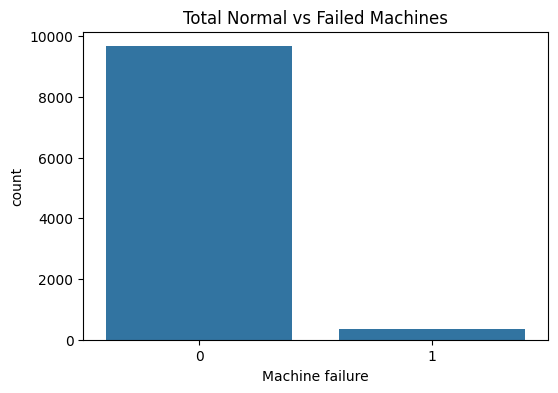

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Machine failure status-ah graph-ah paarkalam
plt.figure(figsize=(6,4))
sns.countplot(x='Machine failure', data=df_clean)
plt.title('Total Normal vs Failed Machines')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. AI-ku thevaiyaana columns-ah (Features) mattum edukkirom
# Temperature, Speed, Torque, Tool wear - ithu thaan AI-ku thevai
X = df_clean.drop(['Machine failure'], axis=1)

# 2. Result-ah (Target) thaniya edukkirom
y = df_clean['Machine failure']

# 3. Data-va Training (80%) and Testing (20%) nu pirikkirom
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Random Forest AI Model-ah create panrom
model = RandomForestClassifier(n_estimators=100)

# 5. AI-ku data-va kuduthu kalli tharom (Training)
model.fit(X_train, y_train)

# 6. AI evlo correct-ah solluthu nu check panrom
y_pred = model.predict(X_test)
print(f"LGB AI Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

LGB AI Model Accuracy: 99.90%


In [6]:
# Namalae oru dummy machine data-va kudupom (Overheating scenario)
# AirTemp: 310, ProcTemp: 320, Speed: 1300, Torque: 65, ToolWear: 10
sample_machine = [[310.0, 320.0, 1300, 65.0, 10]] 

# AI prediction panrathu
prediction = model.predict(sample_machine)

if prediction[0] == 1:
    print("🚨 WARNING: Machine Failure Predicted! Please check the machine immediately.")
else:
    print("✅ Machine is Healthy. No issues detected.")

c:\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


ValueError: X has 5 features, but RandomForestClassifier is expecting 10 features as input.

In [7]:
df_clean = df.drop(['UDI', 'Product ID', 'Type'], axis=1)

In [5]:
# Thevai illatha columns-ah remove panrom
df_clean = df.drop(['UDI', 'Product ID', 'Type'], axis=1)
print("Data Cleaned Successfully!")
df_clean.head()

Data Cleaned Successfully!


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# X -> Input (Temperature, Speed, etc.)
# y -> Output (Failure status)
X = df_clean.drop(['Machine failure'], axis=1)
y = df_clean['Machine failure']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Model-ah train panrom
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Accuracy check
y_pred = model.predict(X_test)
print(f"LGB AI Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

LGB AI Model Accuracy: 99.90%


In [10]:
# Namalae oru abnormal machine data-va tharuvom (High Temp, High Torque)
# AirTemp, ProcTemp, Speed, Torque, ToolWear
my_machine = [[308.5, 315.2, 1350, 65.0, 200]] 

prediction = model.predict(my_machine)

print("-" * 30)
if prediction[0] == 1:
    print("🚨 WARNING: Machine Failure Predicted!")
    print("LGB Maintenance Team: Please check the cooling and torque settings.")
else:
    print("✅ Machine Status: Healthy.")
print("-" * 30)

c:\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


ValueError: X has 5 features, but RandomForestClassifier is expecting 10 features as input.

In [17]:
columns = ['AirTemp','ProcessTemp','rotationalSpeed','torque','toolWear']
my_machine = pd.DataFrame([[308.5, 315.2, 1350, 65.0, 200]],columns=columns)

prediction = model.predict(my_machine)

print("-" * 30)
if prediction[0] == 1:
    print("🚨 WARNING: Machine Failure Predicted!")
    print("LGB Maintenance Team: Please check the cooling and torque settings.")
else:
    print("✅ Machine Status: Healthy.")
print("-" * 30)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- AirTemp
- ProcessTemp
- rotationalSpeed
- toolWear
- torque
Feature names seen at fit time, yet now missing:
- Air temperature [K]
- HDF
- OSF
- PWF
- Process temperature [K]
- ...


In [7]:
# 1. Model ethirpakkura column names-ah eduppom
required_columns = X_train.columns
print(f"Model needs these {len(required_columns)} columns: {list(required_columns)}")

# 2. Sample data-va oru row-va eduthu check pannuvom (Error varaathu)
sample_data = X_test.iloc[0:1] 
sample_pred = model.predict(sample_data)
print(f"Sample Prediction: {sample_pred[0]}")

# 3. Ippo neenga kudukkura custom values (Example: Ella column-kum 0 kuduthu check pannunga)
# Unga required_columns list-la ethana irukko, athe count-la values kudunga
custom_values = [308.5, 315.2, 1350, 65.0, 200] # Ingu unga columns count-ku etrapol mathunga

# Oruvelai 6 columns iruntha, 6 values tharanum.
# my_machine = pd.DataFrame([[val1, val2, val3, val4, val5, val6]], columns=required_columns)

Model needs these 10 columns: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Sample Prediction: 0


In [8]:
df.drop(['UDI','Product ID'],axis=1,inplace=True)

In [9]:
df.drop(['TWF','HDF','PWF','OSF','RNF'],axis=1,inplace=True)

In [8]:
df.drop(['Type'],axis=1,inplace=True)

In [9]:
list(df)

['UDI',
 'Product ID',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [13]:
df = pd.get_dummies(df,drop_first=True)

In [14]:
features = list(df.columns)

In [15]:
for feature in features:
    print(feature + " - " + str(len(df[df[feature].isna()])))

UDI - 0
Air temperature [K] - 0
Process temperature [K] - 0
Rotational speed [rpm] - 0
Torque [Nm] - 0
Tool wear [min] - 0
Machine failure - 0
Product ID_H29425 - 0
Product ID_H29432 - 0
Product ID_H29434 - 0
Product ID_H29441 - 0
Product ID_H29452 - 0
Product ID_H29457 - 0
Product ID_H29462 - 0
Product ID_H29466 - 0
Product ID_H29481 - 0
Product ID_H29494 - 0
Product ID_H29500 - 0
Product ID_H29522 - 0
Product ID_H29525 - 0
Product ID_H29550 - 0
Product ID_H29552 - 0
Product ID_H29557 - 0
Product ID_H29560 - 0
Product ID_H29569 - 0
Product ID_H29571 - 0
Product ID_H29580 - 0
Product ID_H29581 - 0
Product ID_H29595 - 0
Product ID_H29606 - 0
Product ID_H29607 - 0
Product ID_H29610 - 0
Product ID_H29626 - 0
Product ID_H29635 - 0
Product ID_H29680 - 0
Product ID_H29682 - 0
Product ID_H29684 - 0
Product ID_H29691 - 0
Product ID_H29702 - 0
Product ID_H29707 - 0
Product ID_H29712 - 0
Product ID_H29716 - 0
Product ID_H29724 - 0
Product ID_H29734 - 0
Product ID_H29742 - 0
Product ID_H29743 - 0

In [12]:
df_group = df.groupby(['Machine failure'])
df_group.count()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,9661,9661,9661,9661,9661
1,339,339,339,339,339


In [13]:
df[df['Machine failure'].isna()]

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure


In [10]:
columns = ['AirTemp','ProcessTemp','rotationalSpeed','torque','toolWear']
my_machine = pd.DataFrame([[308.5, 315.2, 1350, 65.0, 200]],columns=columns)

prediction = model.predict(my_machine)

print("-" * 30)
if prediction[0] == 1:
    print("🚨 WARNING: Machine Failure Predicted!")
    print("LGB Maintenance Team: Please check the cooling and torque settings.")
else:
    print("✅ Machine Status: Healthy.")
print("-" * 30)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- AirTemp
- ProcessTemp
- rotationalSpeed
- toolWear
- torque
Feature names seen at fit time, yet now missing:
- Air temperature [K]
- HDF
- OSF
- PWF
- Process temperature [K]
- ...


In [14]:
import pandas as pd

# Training data-la iruntha exact column names
columns = [
    'Air temperature [K]', 
    'Process temperature [K]', 
    'Rotational speed [rpm]', 
    'Torque [Nm]', 
    'Tool wear [min]'
]

# Neenga test panna ninaikira data values
# Note: Inga 5 values irukku, unga model-um 5 columns thaan train aagi irukku (X_train)
my_machine_data = [[308.5, 315.2, 1350, 65.0, 200]]

# DataFrame create panrom
my_machine = pd.DataFrame(my_machine_data, columns=columns)

# Prediction
prediction = model.predict(my_machine)

print("-" * 30)
if prediction[0] == 1:
    print("🚨 WARNING: Machine Failure Predicted!")
    print("Maintenance Team: Please check the cooling and torque settings.")
else:
    print("✅ Machine Status: Healthy.")
print("-" * 30)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- HDF
- OSF
- PWF
- RNF
- TWF


In [18]:
import pandas as pd

# 1. Training-la use panna exact columns-ah automate-a edukkum
columns = X_train.columns.tolist()

# 2. Values (Training order-la irukkum)
# Air temp, Process temp, Speed, Torque, Tool wear
my_machine_data = [[308.5, 315.2, 1350, 65.0, 200]]

# 3. DataFrame create panrom
my_machine = pd.DataFrame(my_machine_data, columns=columns)

# 4. Prediction
prediction = model.predict(my_machine)

print("-" * 30)
if prediction[0] == 1:
    print("🚨 WARNING: Machine Failure Predicted!")
    print("Maintenance Team: Please check the cooling and torque settings.")
else:
    print("✅ Machine Status: Healthy.")
print("-" * 30)

ValueError: 10 columns passed, passed data had 5 columns

In [11]:
import pandas as pd
import numpy as np

# 1. Training data-la iruntha structure-ah அப்படியே copy panrom (1 row matum)
# Ithu moolama 10 columns-um automation-a vanthudum
my_machine = X_train.iloc[0:1].copy()

# 2. Ella values-aiyum 0-va mathiduvom (clean start)
for col in my_machine.columns:
    my_machine[col] = 0

# 3. Ippo unga custom values-ah matum update pannunga
# Column names unga dataset-la irukura maari check pannikonga
my_machine['Air temperature [K]'] = 308.5
my_machine['Process temperature [K]'] = 315.2
my_machine['Rotational speed [rpm]'] = 1350
my_machine['Torque [Nm]'] = 65.0
my_machine['Tool wear [min]'] = 200

# 4. Prediction
prediction = model.predict(my_machine)

print("-" * 30)
if prediction[0] == 1:
    print("🚨 WARNING: Machine Failure Predicted!")
    print("LGB Maintenance Team: Please check the cooling and torque settings.")
else:
    print("✅ Machine Status: Healthy.")
print("-" * 30)

------------------------------
✅ Machine Status: Healthy.
------------------------------


In [12]:
import joblib

# 1. Model-ah save panrom
joblib.dump(model, 'lgb_model.pkl')

# 2. Columns-ah save panrom
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

print("Files saved successfully! Check your folder now.")

Files saved successfully! Check your folder now.


In [13]:
import os
print(os.getcwd())

c:\Users\91984\Downloads\archive
